# 07. Differential Expression Analysis

## Basal-like vs Luminal A Breast Cancer

### Objective

This notebook identifies genes that are differentially expressed between Basal-like and Luminal A TCGA-BRCA tumours.

### Main goals

1. Load the processed TCGA-BRCA expression and PAM50 metadata.
2. Select Basal-like and Luminal A tumour samples.
3. Perform gene-level differential expression analysis.
4. Identify significantly upregulated and downregulated genes.
5. Visualise results using volcano plots and ranked expression summaries.
6. Prepare significant gene lists for downstream pathway enrichment analysis.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

print("Project directory:", project_dir)

Project directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA


In [4]:
metadata_file = (
    processed_dir / "tcga_brca_expression_pam50_metadata.csv"
)

metadata = pd.read_csv(metadata_file)

print("Metadata shape:", metadata.shape)

print("\nPAM50 subtype distribution:")
print(metadata["pam50_subtype"].value_counts())

display(metadata.head())

Metadata shape: (981, 5)

PAM50 subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


,sample_id,patient_id,sample_type_code,pam50_subtype,vial
0,TCGA-3C-AAAU-01A,TCGA-3C-AAAU,1,Luminal A,A
1,TCGA-3C-AALI-01A,TCGA-3C-AALI,1,HER2-enriched,A
2,TCGA-3C-AALJ-01A,TCGA-3C-AALJ,1,Luminal B,A
3,TCGA-3C-AALK-01A,TCGA-3C-AALK,1,Luminal A,A
4,TCGA-4H-AAAK-01A,TCGA-4H-AAAK,1,Luminal A,A


In [5]:
expression_file = (
    raw_dir / "TCGA-BRCA.star_counts.tsv.gz"
)

print("Expression file exists:", expression_file.exists())

expression_df = pd.read_csv(
    expression_file,
    sep="\t",
    compression="gzip"
)

print("Expression matrix shape:", expression_df.shape)

Expression file exists: True
Expression matrix shape: (60660, 1227)


In [6]:
comparison_metadata = metadata[
    metadata["pam50_subtype"].isin(
        ["Basal-like", "Luminal A"]
    )
].copy()

print("Comparison sample count:")
print(comparison_metadata["pam50_subtype"].value_counts())

print(
    "\nTotal comparison samples:",
    len(comparison_metadata)
)

Comparison sample count:
pam50_subtype
Luminal A     499
Basal-like    171
Name: count, dtype: int64

Total comparison samples: 670


In [7]:
comparison_sample_ids = (
    comparison_metadata["sample_id"].tolist()
)

expr_comparison = (
    expression_df[
        ["Ensembl_ID"] + comparison_sample_ids
    ]
    .set_index("Ensembl_ID")
)

print("Comparison expression matrix shape:")
print(expr_comparison.shape)

Comparison expression matrix shape:
(60660, 670)


In [8]:
# Filter low-expression genes

min_samples_expressed = int(expr_comparison.shape[1] * 0.20)

genes_expressed = (
    (expr_comparison > 1)
    .sum(axis=1)
)

expr_de = expr_comparison.loc[
    genes_expressed >= min_samples_expressed
].copy()

print("Genes before filtering:", expr_comparison.shape[0])
print("Minimum samples required:", min_samples_expressed)
print("Genes after filtering:", expr_de.shape[0])
print("Genes removed:", expr_comparison.shape[0] - expr_de.shape[0])

Genes before filtering: 60660
Minimum samples required: 134
Genes after filtering: 33520
Genes removed: 27140


In [9]:
# Separate Basal-like and Luminal A samples

basal_samples = comparison_metadata.loc[
    comparison_metadata["pam50_subtype"] == "Basal-like",
    "sample_id"
].tolist()

luminal_a_samples = comparison_metadata.loc[
    comparison_metadata["pam50_subtype"] == "Luminal A",
    "sample_id"
].tolist()

print("Basal-like samples:", len(basal_samples))
print("Luminal A samples:", len(luminal_a_samples))

Basal-like samples: 171
Luminal A samples: 499


In [10]:
# Calculate group mean expression and effect size

basal_mean = expr_de[basal_samples].mean(axis=1)
luminal_a_mean = expr_de[luminal_a_samples].mean(axis=1)

mean_difference = basal_mean - luminal_a_mean

de_results = pd.DataFrame({
    "mean_basal": basal_mean,
    "mean_luminal_a": luminal_a_mean,
    "mean_difference": mean_difference
})

print("DE result table shape:", de_results.shape)

print("\nMean-difference summary:")
print(de_results["mean_difference"].describe())

display(de_results.head())

DE result table shape: (33520, 3)

Mean-difference summary:
count    33520.000000
mean        -0.047021
std          0.952059
min         -9.356053
25%         -0.448597
50%         -0.024176
75%          0.386809
max          6.500537
Name: mean_difference, dtype: float64


,mean_basal,mean_luminal_a,mean_difference
Ensembl_ID,,,
ENSG00000000003.15,11.776748,11.174279,0.602469
ENSG00000000005.6,3.186637,4.107353,-0.920716
ENSG00000000419.13,11.344123,10.904344,0.439779
ENSG00000000457.14,10.120520,10.669097,-0.548577
ENSG00000000460.17,9.941960,9.048020,0.893939


In [11]:
# Mann–Whitney U test for each gene

p_values = []

for gene in expr_de.index:
    basal_values = expr_de.loc[gene, basal_samples]
    luminal_values = expr_de.loc[gene, luminal_a_samples]

    _, p_value = mannwhitneyu(
        basal_values,
        luminal_values,
        alternative="two-sided"
    )

    p_values.append(p_value)

de_results["p_value"] = p_values

print("Statistical testing complete.")

print("\nP-value summary:")
print(de_results["p_value"].describe())

Statistical testing complete.

P-value summary:
count    3.352000e+04
mean     9.747967e-02
std      2.184936e-01
min      9.904449e-85
25%      4.168033e-15
50%      7.052577e-06
75%      3.722711e-02
max      1.000000e+00
Name: p_value, dtype: float64


In [12]:
# Benjamini-Hochberg FDR correction

reject, adjusted_p_values, _, _ = multipletests(
    de_results["p_value"],
    method="fdr_bh"
)

de_results["FDR"] = adjusted_p_values

print("FDR correction complete.")

print(
    "Genes with FDR < 0.05:",
    (de_results["FDR"] < 0.05).sum()
)

FDR correction complete.
Genes with FDR < 0.05: 25151


In [13]:
# Define biologically meaningful differential expression

de_results["regulation"] = "Not significant"

de_results.loc[
    (de_results["FDR"] < 0.05)
    & (de_results["mean_difference"] >= 1),
    "regulation"
] = "Basal-up"

de_results.loc[
    (de_results["FDR"] < 0.05)
    & (de_results["mean_difference"] <= -1),
    "regulation"
] = "LuminalA-up"

print("Differential expression classification:")
print(de_results["regulation"].value_counts())

Differential expression classification:
regulation
Not significant    27433
LuminalA-up         3250
Basal-up            2837
Name: count, dtype: int64


In [14]:
# DE summary

n_basal_up = (de_results["regulation"] == "Basal-up").sum()
n_luminal_up = (de_results["regulation"] == "LuminalA-up").sum()

print("Basal-like upregulated genes:", n_basal_up)
print("Luminal A upregulated genes:", n_luminal_up)
print(
    "Total large-effect DE genes:",
    n_basal_up + n_luminal_up
)

Basal-like upregulated genes: 2837
Luminal A upregulated genes: 3250
Total large-effect DE genes: 6087


In [15]:
# Load GENCODE v36 gene annotation

gencode_file = raw_dir / "gencode.v36.annotation.gtf.gz"

gencode_gtf = pd.read_csv(
    gencode_file,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chromosome",
        "source",
        "feature",
        "start",
        "end",
        "score",
        "strand",
        "frame",
        "attribute"
    ],
    compression="gzip"
)

genes_gtf = gencode_gtf[
    gencode_gtf["feature"] == "gene"
].copy()

genes_gtf["Ensembl_ID"] = (
    genes_gtf["attribute"]
    .str.extract(r'gene_id "([^"]+)"')[0]
    .str.split(".")
    .str[0]
)

genes_gtf["gene_symbol"] = (
    genes_gtf["attribute"]
    .str.extract(r'gene_name "([^"]+)"')[0]
)

gene_annotation = (
    genes_gtf[
        ["Ensembl_ID", "gene_symbol"]
    ]
    .drop_duplicates()
)

print("Gene annotation rows:", len(gene_annotation))

Gene annotation rows: 60616


In [16]:
# Add gene symbols to differential expression results

de_results_annot = de_results.copy()

de_results_annot["Ensembl_ID_versioned"] = (
    de_results_annot.index
)

de_results_annot["Ensembl_ID"] = (
    de_results_annot["Ensembl_ID_versioned"]
    .str.split(".")
    .str[0]
)

de_results_annot = (
    de_results_annot
    .reset_index(drop=True)
    .merge(
        gene_annotation,
        on="Ensembl_ID",
        how="left"
    )
)

print(
    "Genes with mapped symbols:",
    de_results_annot["gene_symbol"].notna().sum()
)

print(
    "Genes without mapped symbols:",
    de_results_annot["gene_symbol"].isna().sum()
)

Genes with mapped symbols: 33520
Genes without mapped symbols: 0


In [17]:
print("Top Basal-like upregulated genes:")

display(
    de_results_annot[
        de_results_annot["regulation"] == "Basal-up"
    ]
    .sort_values("mean_difference", ascending=False)
    [
        [
            "gene_symbol",
            "mean_basal",
            "mean_luminal_a",
            "mean_difference",
            "FDR"
        ]
    ]
    .head(20)
)

print("\nTop Luminal A upregulated genes:")

display(
    de_results_annot[
        de_results_annot["regulation"] == "LuminalA-up"
    ]
    .sort_values("mean_difference")
    [
        [
            "gene_symbol",
            "mean_basal",
            "mean_luminal_a",
            "mean_difference",
            "FDR"
        ]
    ]
    .head(20)
)

Top Basal-like upregulated genes:


,gene_symbol,mean_basal,mean_luminal_a,mean_difference,FDR
31840,FOXCUT,9.143688,2.643152,6.500537,7.524514e-79
2591,VGLL1,9.994718,3.779097,6.215620,1.595720e-63
16795,CT83,6.299500,0.210827,6.088673,3.106024e-69
9572,ART3,8.795816,2.763126,6.032691,5.413754e-63
913,ROPN1,8.766660,2.790707,5.975954,5.776074e-69
8105,HORMAD1,8.176952,2.294338,5.882613,8.096446e-51
11395,A2ML1,10.212901,4.340520,5.872381,1.510567e-63
27462,LINC02188,9.909252,4.310084,5.599167,1.205224e-64
14936,PRAME,10.221689,4.637394,5.584296,1.210593e-40
7114,GABBR2,7.498624,1.967237,5.531387,3.411643e-65



Top Luminal A upregulated genes:


,gene_symbol,mean_basal,mean_luminal_a,mean_difference,FDR
10030,TFF1,2.671034,12.027086,-9.356053,3.939545e-76
12852,AGR3,4.050617,12.735939,-8.685322,1.300630e-79
8765,ANKRD30A,2.434658,10.677868,-8.243211,8.518765e-69
22259,LINC00993,2.762596,10.981368,-8.218772,1.165663e-68
10028,TFF3,5.238552,13.042245,-7.803693,2.272852e-76
26118,CYP2B7P,3.719387,11.129659,-7.410272,1.239512e-71
12030,GP2,2.161885,9.560939,-7.399054,6.270923e-70
14572,SRARP,1.100093,8.499047,-7.398954,5.960227e-78
22017,AL157387.1,1.339041,8.707546,-7.368505,5.113220e-69
3239,AGR2,7.454974,14.773713,-7.318738,6.546774e-78


In [18]:
# Prepare volcano plot variables

de_results_annot["minus_log10_FDR"] = (
    -np.log10(
        de_results_annot["FDR"].clip(lower=1e-300)
    )
)

print(de_results_annot[
    [
        "gene_symbol",
        "mean_difference",
        "FDR",
        "regulation",
        "minus_log10_FDR"
    ]
].head())

  gene_symbol  mean_difference           FDR       regulation  minus_log10_FDR
0      TSPAN6         0.602469  6.204619e-10  Not significant         9.207285
1        TNMD        -0.920716  1.341944e-06  Not significant         5.872266
2        DPM1         0.439779  2.320756e-15  Not significant        14.634371
3       SCYL3        -0.548577  8.924175e-14  Not significant        13.049432
4    C1orf112         0.893939  8.436685e-24  Not significant        23.073828


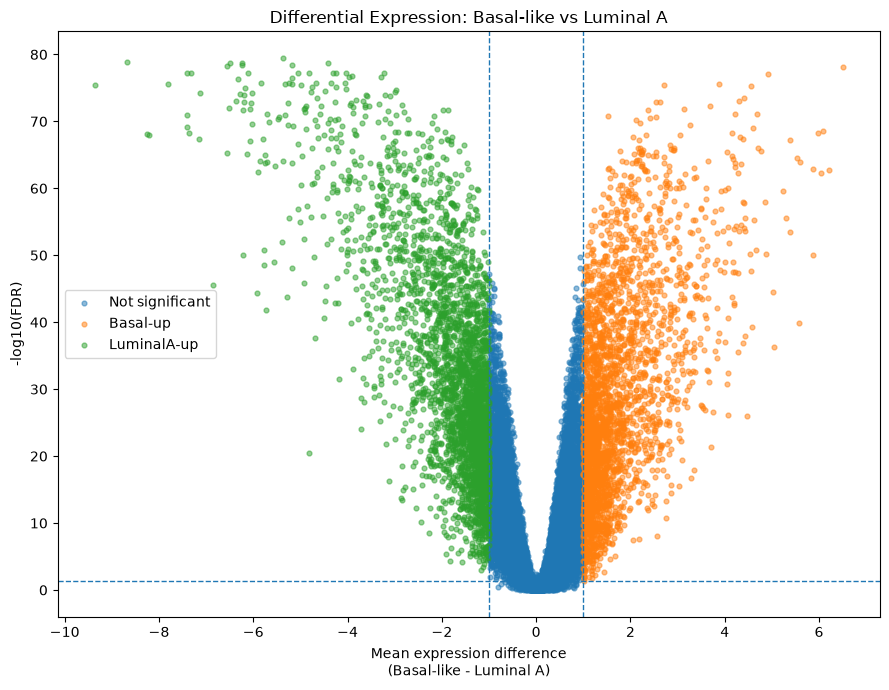

In [19]:
# Volcano plot: Basal-like vs Luminal A

plt.figure(figsize=(9, 7))

for group in [
    "Not significant",
    "Basal-up",
    "LuminalA-up"
]:
    subset = de_results_annot[
        de_results_annot["regulation"] == group
    ]

    plt.scatter(
        subset["mean_difference"],
        subset["minus_log10_FDR"],
        s=12,
        alpha=0.5,
        label=group
    )

plt.axvline(
    1,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    -1,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Mean expression difference\n(Basal-like - Luminal A)"
)

plt.ylabel("-log10(FDR)")

plt.title(
    "Differential Expression: Basal-like vs Luminal A"
)

plt.legend()

plt.tight_layout()
plt.show()

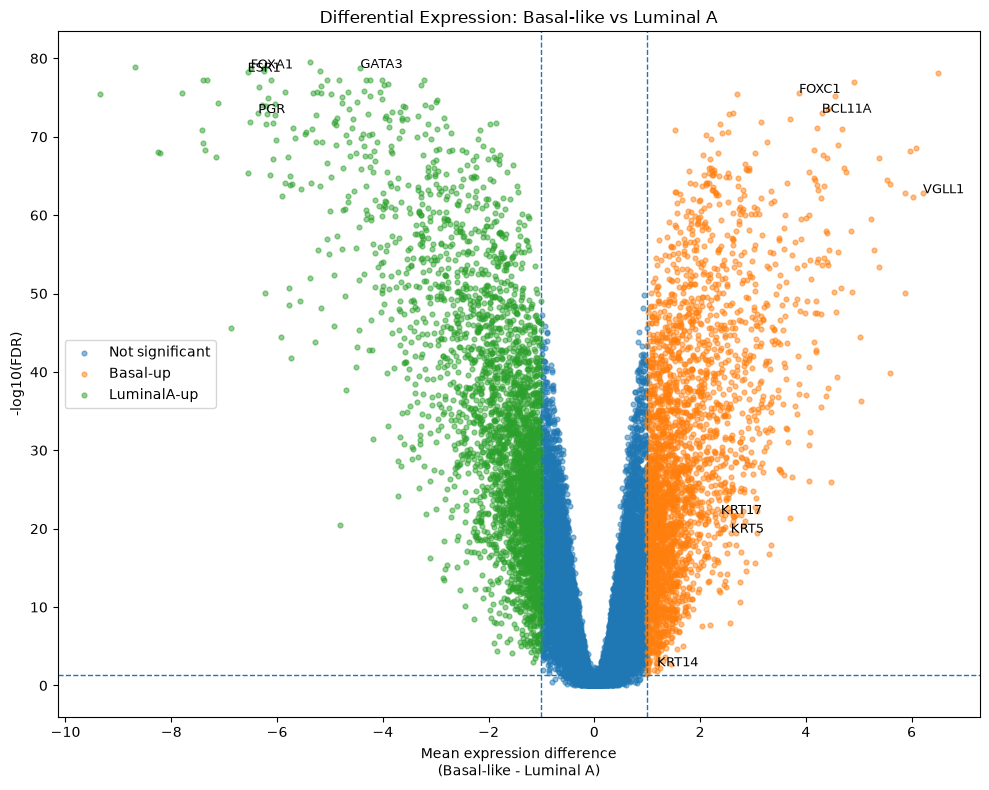

In [20]:
# Add labels for selected biologically relevant genes

genes_to_label = [
    "FOXC1",
    "KRT5",
    "KRT14",
    "KRT17",
    "BCL11A",
    "VGLL1",
    "ESR1",
    "PGR",
    "FOXA1",
    "GATA3"
]

plt.figure(figsize=(10, 8))

for group in [
    "Not significant",
    "Basal-up",
    "LuminalA-up"
]:
    subset = de_results_annot[
        de_results_annot["regulation"] == group
    ]

    plt.scatter(
        subset["mean_difference"],
        subset["minus_log10_FDR"],
        s=12,
        alpha=0.5,
        label=group
    )

plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle="--", linewidth=1)
plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

for gene in genes_to_label:
    gene_row = de_results_annot[
        de_results_annot["gene_symbol"] == gene
    ]

    if len(gene_row) > 0:
        x = gene_row.iloc[0]["mean_difference"]
        y = gene_row.iloc[0]["minus_log10_FDR"]

        plt.text(
            x,
            y,
            gene,
            fontsize=9
        )

plt.xlabel(
    "Mean expression difference\n(Basal-like - Luminal A)"
)

plt.ylabel("-log10(FDR)")

plt.title(
    "Differential Expression: Basal-like vs Luminal A"
)

plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Save full annotated differential expression results

de_results_path = (
    results_dir /
    "07_basal_vs_luminalA_differential_expression.csv"
)

de_results_annot.to_csv(
    de_results_path,
    index=False
)

print("Saved differential expression results to:")
print(de_results_path)

Saved differential expression results to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/07_basal_vs_luminalA_differential_expression.csv


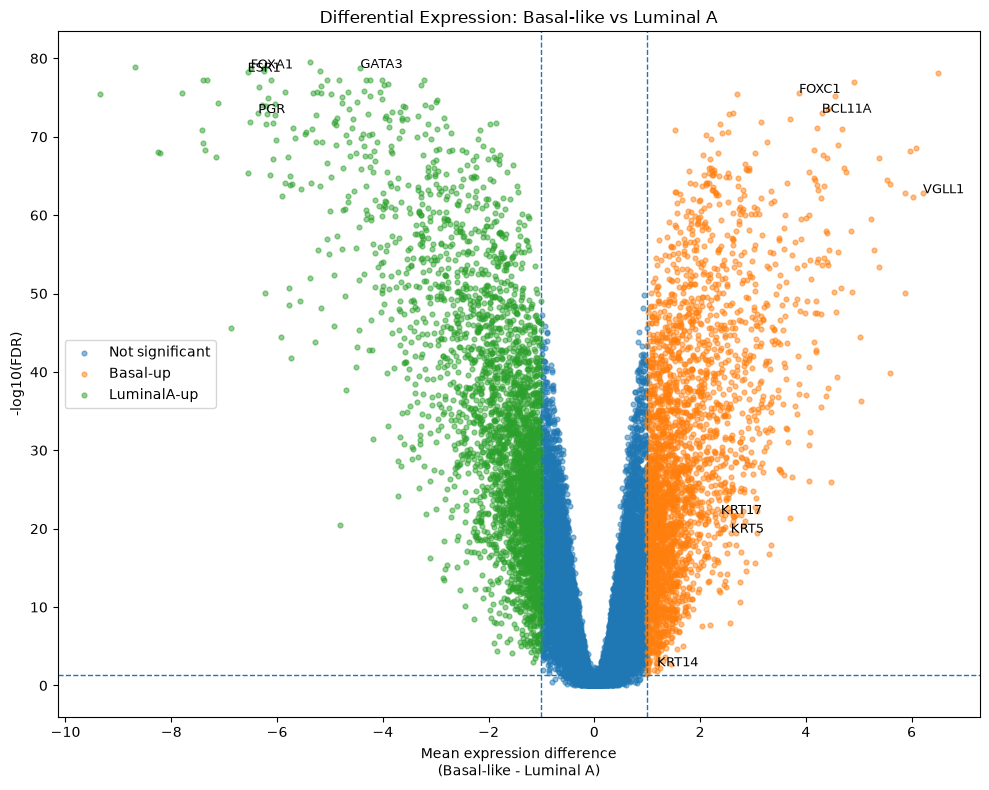

Saved volcano plot to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/figures/07_basal_vs_luminalA_volcano_plot.png


In [22]:
# Save labelled volcano plot

volcano_figure_path = (
    figures_dir / "07_basal_vs_luminalA_volcano_plot.png"
)

plt.figure(figsize=(10, 8))

for group in [
    "Not significant",
    "Basal-up",
    "LuminalA-up"
]:
    subset = de_results_annot[
        de_results_annot["regulation"] == group
    ]

    plt.scatter(
        subset["mean_difference"],
        subset["minus_log10_FDR"],
        s=12,
        alpha=0.5,
        label=group
    )

plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(-1, linestyle="--", linewidth=1)
plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

for gene in genes_to_label:
    gene_row = de_results_annot[
        de_results_annot["gene_symbol"] == gene
    ]

    if len(gene_row) > 0:
        x = gene_row.iloc[0]["mean_difference"]
        y = gene_row.iloc[0]["minus_log10_FDR"]

        plt.text(
            x,
            y,
            gene,
            fontsize=9
        )

plt.xlabel(
    "Mean expression difference\n(Basal-like - Luminal A)"
)
plt.ylabel("-log10(FDR)")
plt.title(
    "Differential Expression: Basal-like vs Luminal A"
)
plt.legend()

plt.tight_layout()

plt.savefig(
    volcano_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved volcano plot to:")
print(volcano_figure_path)

In [23]:
# Save Basal-like upregulated genes

basal_up_results = (
    de_results_annot[
        de_results_annot["regulation"] == "Basal-up"
    ]
    .sort_values("mean_difference", ascending=False)
)

basal_up_path = (
    results_dir / "07_basal_up_genes.csv"
)

basal_up_results.to_csv(
    basal_up_path,
    index=False
)

print("Saved Basal-up genes to:")
print(basal_up_path)

Saved Basal-up genes to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/07_basal_up_genes.csv


In [24]:
# Save Luminal A upregulated genes

luminal_up_results = (
    de_results_annot[
        de_results_annot["regulation"] == "LuminalA-up"
    ]
    .sort_values("mean_difference")
)

luminal_up_path = (
    results_dir / "07_luminalA_up_genes.csv"
)

luminal_up_results.to_csv(
    luminal_up_path,
    index=False
)

print("Saved LuminalA-up genes to:")
print(luminal_up_path)

Saved LuminalA-up genes to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/07_luminalA_up_genes.csv


In [25]:
# Save Luminal A upregulated genes

luminal_up_results = (
    de_results_annot[
        de_results_annot["regulation"] == "LuminalA-up"
    ]
    .sort_values("mean_difference")
)

luminal_up_path = (
    results_dir / "07_luminalA_up_genes.csv"
)

luminal_up_results.to_csv(
    luminal_up_path,
    index=False
)

print("Saved LuminalA-up genes to:")
print(luminal_up_path)

Saved LuminalA-up genes to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/07_luminalA_up_genes.csv


In [26]:
# Top 20 genes for each direction

top_basal_20 = basal_up_results[
    [
        "gene_symbol",
        "mean_basal",
        "mean_luminal_a",
        "mean_difference",
        "FDR"
    ]
].head(20)

top_luminal_20 = luminal_up_results[
    [
        "gene_symbol",
        "mean_basal",
        "mean_luminal_a",
        "mean_difference",
        "FDR"
    ]
].head(20)

print("Top 20 Basal-like upregulated genes:")
display(top_basal_20)

print("\nTop 20 Luminal A upregulated genes:")
display(top_luminal_20)

Top 20 Basal-like upregulated genes:


,gene_symbol,mean_basal,mean_luminal_a,mean_difference,FDR
31840,FOXCUT,9.143688,2.643152,6.500537,7.524514e-79
2591,VGLL1,9.994718,3.779097,6.215620,1.595720e-63
16795,CT83,6.299500,0.210827,6.088673,3.106024e-69
9572,ART3,8.795816,2.763126,6.032691,5.413754e-63
913,ROPN1,8.766660,2.790707,5.975954,5.776074e-69
8105,HORMAD1,8.176952,2.294338,5.882613,8.096446e-51
11395,A2ML1,10.212901,4.340520,5.872381,1.510567e-63
27462,LINC02188,9.909252,4.310084,5.599167,1.205224e-64
14936,PRAME,10.221689,4.637394,5.584296,1.210593e-40
7114,GABBR2,7.498624,1.967237,5.531387,3.411643e-65



Top 20 Luminal A upregulated genes:


,gene_symbol,mean_basal,mean_luminal_a,mean_difference,FDR
10030,TFF1,2.671034,12.027086,-9.356053,3.939545e-76
12852,AGR3,4.050617,12.735939,-8.685322,1.300630e-79
8765,ANKRD30A,2.434658,10.677868,-8.243211,8.518765e-69
22259,LINC00993,2.762596,10.981368,-8.218772,1.165663e-68
10028,TFF3,5.238552,13.042245,-7.803693,2.272852e-76
26118,CYP2B7P,3.719387,11.129659,-7.410272,1.239512e-71
12030,GP2,2.161885,9.560939,-7.399054,6.270923e-70
14572,SRARP,1.100093,8.499047,-7.398954,5.960227e-78
22017,AL157387.1,1.339041,8.707546,-7.368505,5.113220e-69
3239,AGR2,7.454974,14.773713,-7.318738,6.546774e-78


In [27]:
# Final QC for Notebook 07

print("=== FINAL DIFFERENTIAL EXPRESSION ANALYSIS QC ===")

print(f"Total comparison samples: {len(comparison_metadata)}")
print(f"Luminal A samples: {len(luminal_a_samples)}")
print(f"Basal-like samples: {len(basal_samples)}")

print(f"\nGenes before filtering: {expr_comparison.shape[0]}")
print(f"Genes after filtering: {expr_de.shape[0]}")

print(
    f"\nGenes with FDR < 0.05: "
    f"{(de_results['FDR'] < 0.05).sum()}"
)

print(
    f"Basal-like upregulated genes: "
    f"{(de_results['regulation'] == 'Basal-up').sum()}"
)

print(
    f"Luminal A upregulated genes: "
    f"{(de_results['regulation'] == 'LuminalA-up').sum()}"
)

print(
    f"Total large-effect DE genes: "
    f"{((de_results['regulation'] == 'Basal-up').sum() + (de_results['regulation'] == 'LuminalA-up').sum())}"
)

print("\nExample Basal markers labelled:")
print("FOXC1, BCL11A, VGLL1, KRT5, KRT14, KRT17")

print("\nExample Luminal markers labelled:")
print("ESR1, PGR, FOXA1, GATA3")

=== FINAL DIFFERENTIAL EXPRESSION ANALYSIS QC ===
Total comparison samples: 670
Luminal A samples: 499
Basal-like samples: 171

Genes before filtering: 60660
Genes after filtering: 33520

Genes with FDR < 0.05: 25151
Basal-like upregulated genes: 2837
Luminal A upregulated genes: 3250
Total large-effect DE genes: 6087

Example Basal markers labelled:
FOXC1, BCL11A, VGLL1, KRT5, KRT14, KRT17

Example Luminal markers labelled:
ESR1, PGR, FOXA1, GATA3
